In [156]:
import sys, os

# Ensure project root (parent of dev/) is in sys.path regardless of CWD
_here = os.getcwd()
_root = os.path.abspath('..') if os.path.basename(_here) == 'dev' else os.path.abspath('.')
if _root not in sys.path:
    sys.path.insert(0, _root)
print("project root on sys.path:", _root)

project root on sys.path: e:\dataset


In [157]:
import os
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms as T


In [158]:
DATASET_ROOT = os.path.abspath(os.path.join("../data"))

In [159]:
from src   import CheXpertDataset, ChestXray8Dataset, VinBigDataset, UnifiedDataset, ProjectionStrategy, ViewStrategy, CANONICAL_LABELS
from transforms import FourierAmplitudeMixup

# Instanciar datasets
# Construir DataLoaders
# Visualizar distribución
# Verificar batch

# Clases Unified para train, test, val

## train_unified

In [160]:
train_ids = set(open(os.path.join(DATASET_ROOT, "ChestXray8", "train_val_list.txt")).read().splitlines())

train_chexpert = CheXpertDataset(
    root = DATASET_ROOT,
    csv_path   = os.path.join(DATASET_ROOT, "chexpert", "train.csv"),
    images_dir =  os.path.join(DATASET_ROOT,"chexpert","train"),
    projection=ProjectionStrategy.ALL,
    view=ViewStrategy.FRONTAL_ONLY
)
train_chest8 = ChestXray8Dataset(
    root = DATASET_ROOT,
    csv_path   = os.path.join(DATASET_ROOT, "ChestXray8", "Data_Entry_2017.csv"),
    projection=ProjectionStrategy.ALL,
    split_ids = train_ids,
)


train_unified = UnifiedDataset(datasets={
    "chexpert": train_chexpert,
    "cx8":      train_chest8,
})

## test_unified

In [161]:
test_ids  = set(open(os.path.join(DATASET_ROOT, "ChestXray8", "test_list.txt")).read().splitlines())

test_chexpert = CheXpertDataset(
    root = DATASET_ROOT,
    csv_path   = os.path.join(DATASET_ROOT, "chexpert", "valid.csv"),
    images_dir =  os.path.join(DATASET_ROOT,"chexpert","valid"),
    projection=ProjectionStrategy.ALL,
    view=ViewStrategy.FRONTAL_ONLY
)
test_chest8 = ChestXray8Dataset(
    root = DATASET_ROOT,
    csv_path   = os.path.join(DATASET_ROOT, "ChestXray8", "Data_Entry_2017.csv"),
    projection=ProjectionStrategy.ALL,
    split_ids = test_ids,
)

test_unified = UnifiedDataset(datasets={
    "chexpert": test_chexpert,
    "cx8":      test_chest8,
})

## val_unified

In [162]:
vinbig = VinBigDataset(
    root        = DATASET_ROOT,
    csv_path    = os.path.join(DATASET_ROOT, "VinBigData", "train.csv"),
    images_dirs = [
        os.path.join(DATASET_ROOT, "VinBigData", "train"),
        os.path.join(DATASET_ROOT, "VinBigData", "test"),
    ],
)

val_unified = UnifiedDataset(datasets={
    "vin": vinbig,
})

## Preprocesamiento + Data Augmentation

In [163]:
normalize = T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

base_transforms = T.Compose([
    T.Resize(320),
    T.CenterCrop(224),
    T.ToTensor(),
    normalize,
])

ref_chexpert = CheXpertDataset(
    root = DATASET_ROOT,
    csv_path   = os.path.join(DATASET_ROOT, "chexpert", "train.csv"),
    images_dir =  os.path.join(DATASET_ROOT,"chexpert","train"),
    projection=ProjectionStrategy.ALL,
    view=ViewStrategy.FRONTAL_ONLY
)
ref_chest8   = ChestXray8Dataset(
    root = DATASET_ROOT,
    csv_path   = os.path.join(DATASET_ROOT, "ChestXray8", "Data_Entry_2017.csv"),
    projection=ProjectionStrategy.ALL,
    split_ids = train_ids,
)

fourier_mixup = FourierAmplitudeMixup(
    datasets=[ref_chexpert, ref_chest8],
    beta=0.01,  # fracción del espectro de baja frecuencia a intercambiar
    p=0.5,
)

train_augs = T.Compose([
    # Simula variación en posicionamiento del paciente y campo de visión del colimador.
    # scale=(0.75,1.0) garantiza que al menos el 75% del área es visible,
    # evitando crops que corten estructuras anatómicas críticas.
    # ratio≈1.0 preserva la proporción cuadrada del tórax frontal.
    T.RandomResizedCrop(size=224, scale=(0.75, 1.0), ratio=(0.95, 1.05)),

    # Simula imágenes adquiridas con el paciente orientado hacia la izquierda o derecha.
    # Válido en tórax por simetría bilateral aproximada.
    # NO usar RandomVerticalFlip: pulmones invertidos verticalmente no son anatómicamente válidos.
    T.RandomHorizontalFlip(p=0.5),

    # Simula inclinación del paciente durante la adquisición o rotación leve del tubo de rayos X.
    # 15° es el límite recomendado en literatura — rotaciones mayores distorsionan
    # la relación espacial entre estructuras (mediastino, ángulos costofrénicos).
    T.RandomRotation(degrees=15),

    # Fourier Domain Adaptation (Yang & Soatto, CVPR 2020).
    # Intercambia amplitudes de baja frecuencia con una imagen aleatoria del pool
    # de referencia, preservando la fase (estructura anatómica).
    # Objetivo: reducir domain shift entre CheXpert (Stanford) y ChestX-ray8 (NIH),
    # cuyas diferencias de contraste y brillo global están codificadas en baja frecuencia.
    fourier_mixup,

    T.ToTensor(),
    normalize,
])

train_chexpert.transform = train_augs
train_chest8.transform   = train_augs
vinbig.transform         = base_transforms
test_chexpert.transform  = base_transforms
test_chest8.transform    = base_transforms

# Particionado: Distribución por clase en cada partición

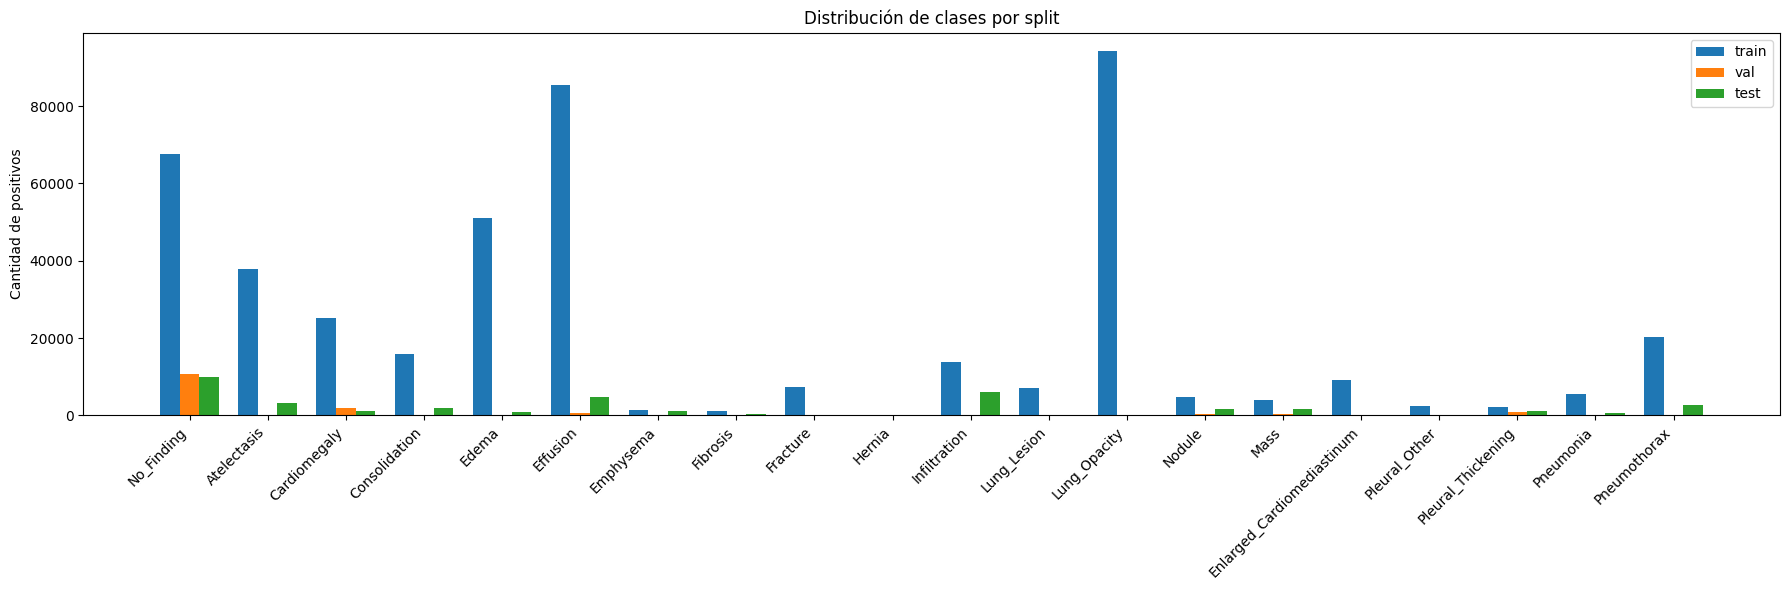

In [164]:
splits = {
    "train": train_unified.class_distribution(),
    "val":   val_unified.class_distribution(),
    "test":  test_unified.class_distribution(),
}

x = np.arange(len(CANONICAL_LABELS))
width = 0.25

fig, ax = plt.subplots(figsize=(18, 6))

for i, (split_name, counts) in enumerate(splits.items()):
    values = [counts[label] for label in CANONICAL_LABELS]
    ax.bar(x + i * width, values, width, label=split_name)

ax.set_xticks(x + width)
ax.set_xticklabels(CANONICAL_LABELS, rotation=45, ha="right")
ax.set_ylabel("Cantidad de positivos")
ax.set_title("Distribución de clases por split")
ax.legend()

plt.tight_layout()
plt.show()

## DataLoaders

In [165]:
BATCH_SIZE=32
NUM_WORKERS=0
torch.manual_seed(42) #shuffle del Dataloader

train_loader = DataLoader(train_unified, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_unified,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_unified,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

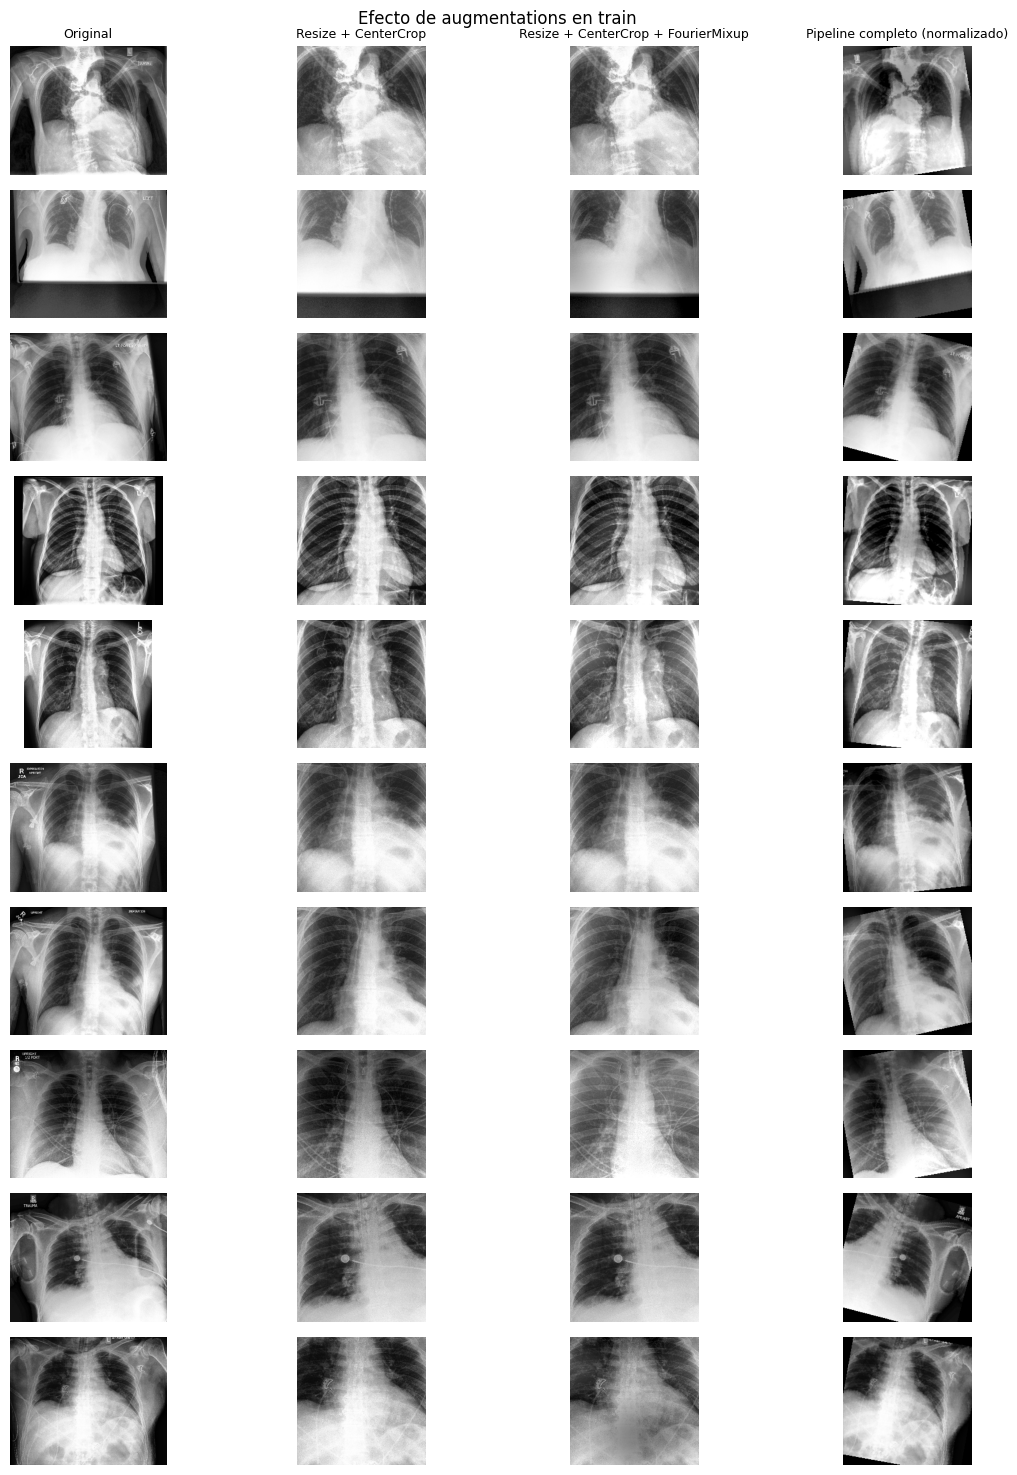

In [166]:
def to_displayable(result):
    if isinstance(result, torch.Tensor):
        img = result.permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min())
        return img.mean(axis=2)  # RGB → escala de grises
    return result

fig, axes = plt.subplots(10, 4, figsize=(12, 15))

col_titles = [
    "Original",
    "Resize + CenterCrop",
    "Resize + CenterCrop + FourierMixup",
    "Pipeline completo (normalizado)"
]

partial_transforms = [
    None,
    T.Compose([T.Resize(320), T.CenterCrop(224)]),
    T.Compose([T.Resize(320), T.CenterCrop(224), fourier_mixup]),
    train_augs,
]

for row_idx in range(10):
    row = train_chexpert.df.iloc[row_idx]
    for col_idx, tf in enumerate(partial_transforms):
        train_chexpert.transform = tf
        ax = axes[row_idx, col_idx]
        ax.imshow(to_displayable(train_chexpert._load_image(row)), cmap="gray")
        ax.axis("off")
        if row_idx == 0:
            ax.set_title(col_titles[col_idx], fontsize=9)

train_chexpert.transform = train_augs
plt.suptitle("Efecto de augmentations en train")
plt.tight_layout()
plt.show()

# Visualizar Batch

Tensor shape : torch.Size([32, 3, 224, 224])  → (batch, canales, alto, ancho)
Rango normalizado : [-2.118, 2.640]
Labels shape : torch.Size([32, 20])


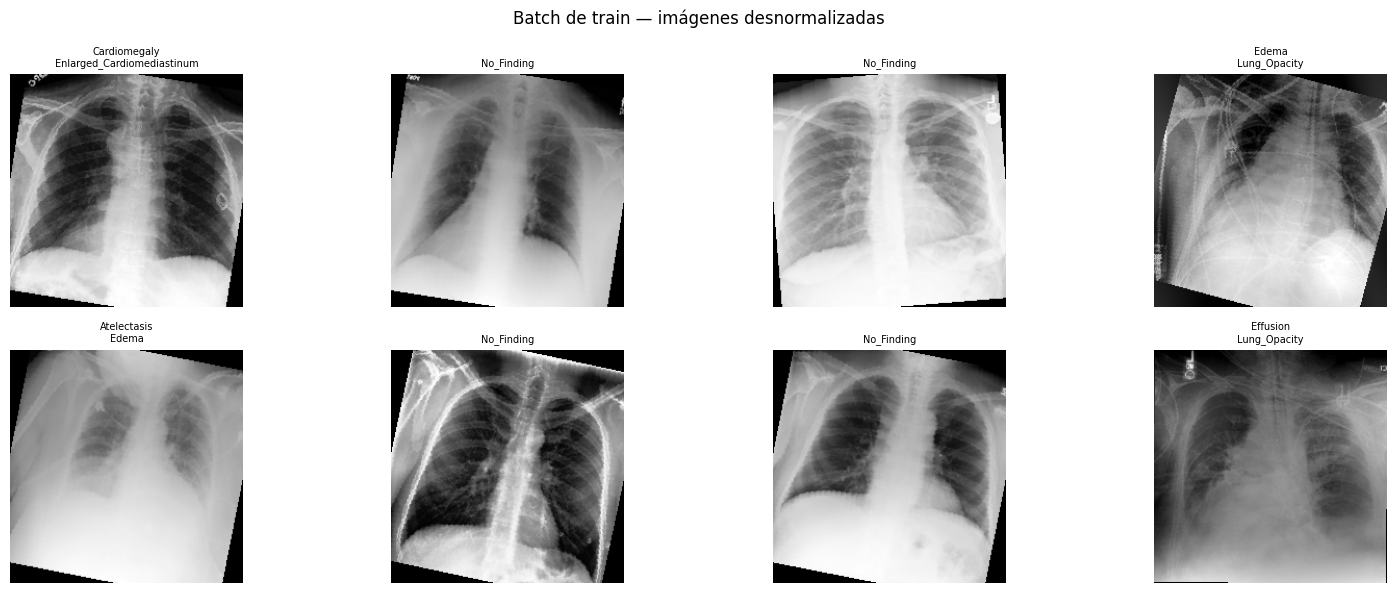

In [167]:
def visualize_batch(loader, n_images=8):
    images, labels = next(iter(loader))

    # Dimensiones y rango
    print(f"Tensor shape : {images.shape}  → (batch, canales, alto, ancho)")
    print(f"Rango normalizado : [{images.min():.3f}, {images.max():.3f}]")
    print(f"Labels shape : {labels.shape}")

    # Desnormalizar para visualización
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    imgs_denorm = (images[:n_images] * std + mean).clamp(0, 1)

    fig, axes = plt.subplots(2, n_images // 2, figsize=(16, 6))
    axes = axes.flatten()

    for i in range(n_images):
        img_vis = imgs_denorm[i].permute(1, 2, 0).numpy().mean(axis=2)
        axes[i].imshow(img_vis, cmap="gray")
        axes[i].axis("off")

        # Etiquetas positivas de esta imagen
        pos = [CANONICAL_LABELS[j] for j, v in enumerate(labels[i]) if v == 1]
        axes[i].set_title("\n".join(pos) if pos else "No Finding", fontsize=7)

    plt.suptitle("Batch de train — imágenes desnormalizadas")
    plt.tight_layout()
    plt.show()

visualize_batch(train_loader)